Libraries imported successfully!

================ DATASET ================

    Study_Hours  Attendance  Previous_Marks  Assignments  Result
0             2          60              45            4       0
1             5          85              72            8       1
2             1          50              38            3       0
3             6          90              85            9       1
4             3          70              55            6       1
5             8          95              90           10       1
6             2          55              48            5       0
7             7          92              88            9       1
8             4          75              65            7       1
9             9          98              95           10       1
10            1          45              35            2       0
11            5          88              78            8       1
12            3          65              52            5       0
13           

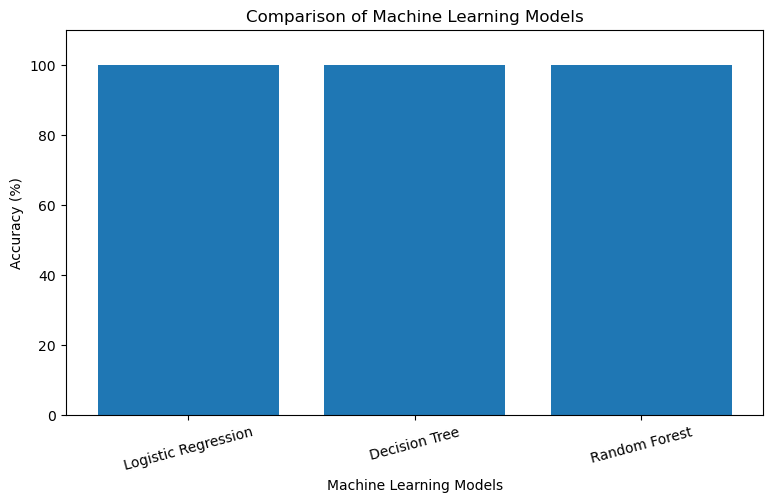


================ CONFUSION MATRIX ================

[[2 0]
 [0 4]]


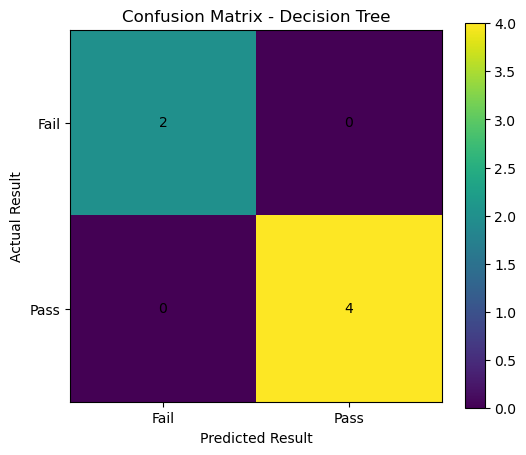


================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


================ FEATURE IMPORTANCE ================

          Feature  Importance
2  Previous_Marks         1.0
0     Study_Hours         0.0
1      Attendance         0.0
3     Assignments         0.0


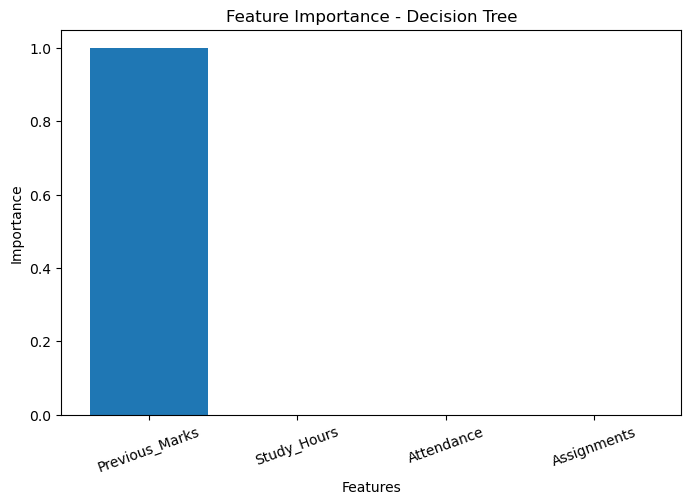


================ NEW STUDENT PREDICTION ================

Prediction: PASS
Probability of Fail: 0.0 %
Probability of Pass: 100.0 %

              PROJECT COMPLETED

Project Title:
Student Performance Prediction Using Machine Learning

Algorithms Used:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Features Used:
1. Study Hours
2. Attendance
3. Previous Marks
4. Assignment Completion

Target:
0 = Fail
1 = Pass

Model Accuracy:
Logistic Regression: 100.0 %
Decision Tree: 100.0 %
Random Forest: 100.0 %


In [2]:

# STUDENT PERFORMANCE PREDICTION USING MACHINE LEARNING

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")




data = {
    "Study_Hours": [
        2, 5, 1, 6, 3, 8, 2, 7, 4, 9,
        1, 5, 3, 8, 2, 6, 4, 7, 1, 9,
        3, 6, 2, 8, 5, 7, 4, 9, 2, 6
    ],

    "Attendance": [
        60, 85, 50, 90, 70, 95, 55, 92, 75, 98,
        45, 88, 65, 94, 58, 82, 72, 91, 48, 97,
        68, 89, 57, 96, 80, 93, 74, 99, 52, 86
    ],

    "Previous_Marks": [
        45, 72, 38, 85, 55, 90, 48, 88, 65, 95,
        35, 78, 52, 92, 42, 75, 68, 86, 40, 96,
        58, 81, 47, 94, 70, 87, 63, 98, 44, 76
    ],

    "Assignments": [
        4, 8, 3, 9, 6, 10, 5, 9, 7, 10,
        2, 8, 5, 10, 4, 8, 7, 9, 3, 10,
        6, 9, 4, 10, 7, 9, 6, 10, 3, 8
    ],

    "Result": [
        0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
        0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
        1, 1, 0, 1, 1, 1, 1, 1, 0, 1
    ]
}

df = pd.DataFrame(data)

print("\n================ DATASET ================\n")
print(df)



print("\n================ DATASET INFO ================\n")
print(df.info())

print("\n================ STATISTICS ================\n")
print(df.describe())




print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())




X = df[
    [
        "Study_Hours",
        "Attendance",
        "Previous_Marks",
        "Assignments"
    ]
]

y = df["Result"]




X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n================ DATA SPLIT ================\n")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))



lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, pred_lr)

print("\n================ LOGISTIC REGRESSION ================\n")
print("Accuracy:", round(accuracy_lr * 100, 2), "%")



dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, pred_dt)

print("\n================ DECISION TREE ================\n")
print("Accuracy:", round(accuracy_dt * 100, 2), "%")



rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, pred_rf)

print("\n================ RANDOM FOREST ================\n")
print("Accuracy:", round(accuracy_rf * 100, 2), "%")



models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    accuracy_lr * 100,
    accuracy_dt * 100,
    accuracy_rf * 100
]

print("\n================ MODEL COMPARISON ================\n")

for model, accuracy in zip(models, accuracies):
    print(model, ":", round(accuracy, 2), "%")




plt.figure(figsize=(9, 5))

plt.bar(models, accuracies)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Machine Learning Models")

plt.xticks(rotation=15)

plt.ylim(0, 110)

plt.show()



cm = confusion_matrix(y_test, pred_dt)

print("\n================ CONFUSION MATRIX ================\n")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Decision Tree")

plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")

plt.colorbar()

plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

# Display values inside matrix
for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(
            j,
            i,
            cm[i][j],
            ha="center",
            va="center"
        )

plt.show()




print("\n================ CLASSIFICATION REPORT ================\n")

print(
    classification_report(
        y_test,
        pred_dt,
        target_names=["Fail", "Pass"]
    )
)



importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n================ FEATURE IMPORTANCE ================\n")
print(importance)




plt.figure(figsize=(8, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Decision Tree")

plt.xticks(rotation=20)

plt.show()




new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [85],
    "Previous_Marks": [75],
    "Assignments": [8]
})

prediction = dt.predict(new_student)

probability = dt.predict_proba(new_student)

print("\n================ NEW STUDENT PREDICTION ================\n")

if prediction[0] == 1:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")

print(
    "Probability of Fail:",
    round(probability[0][0] * 100, 2),
    "%"
)

print(
    "Probability of Pass:",
    round(probability[0][1] * 100, 2),
    "%"
)




print("\n========================================================")
print("              PROJECT COMPLETED")
print("========================================================")

print("\nProject Title:")
print("Student Performance Prediction Using Machine Learning")

print("\nAlgorithms Used:")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")

print("\nFeatures Used:")
print("1. Study Hours")
print("2. Attendance")
print("3. Previous Marks")
print("4. Assignment Completion")

print("\nTarget:")
print("0 = Fail")
print("1 = Pass")

print("\nModel Accuracy:")
print("Logistic Regression:", round(accuracy_lr * 100, 2), "%")
print("Decision Tree:", round(accuracy_dt * 100, 2), "%")
print("Random Forest:", round(accuracy_rf * 100, 2), "%")